In [ ]:
!pip install osmnx geopandas folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 5.8 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
print(ox.__version__)

2.1.1


In [13]:
import os
for f in os.listdir("/content"):
    if f.endswith(".csv"):
        print(repr(f))

'Transit_Stations___Stations_du_transport_en_commun.csv'


In [14]:
import pandas as pd

df = pd.read_csv("/content/Transit_Stations___Stations_du_transport_en_commun.csv")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 40
Columns: ['X', 'Y', 'OBJECTID', 'LON', 'LAT', 'ID', 'NAME']


,X,Y,OBJECTID,LON,LAT,ID,NAME
0,-8.430773e+06,5.685322e+06,1,364692.65,5029606.15,__4KSBNC,Tunney's Pasture
1,-8.432712e+06,5.684151e+06,2,363336.86,5028772.38,__4KSBNE,Westboro
2,-8.428337e+06,5.686942e+06,3,366394.76,5030757.96,__4KSBNG,Lebreton
3,-8.425409e+06,5.688494e+06,4,368442.67,5031866.09,__4KSBOI,Laurier South
4,-8.425411e+06,5.688551e+06,5,368440.32,5031906.03,__4KSBOK,Laurier North


In [15]:
import geopandas as gpd
import folium

# Build a geographic table using the X/Y columns (Web Mercator, EPSG:3857)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X"], df["Y"]),
    crs="EPSG:3857",
)

# Convert to real latitude/longitude (EPSG:4326)
gdf = gdf.to_crs("EPSG:4326")

# Pull the converted lat/long back into plain columns
gdf["lon"] = gdf.geometry.x
gdf["lat"] = gdf.geometry.y

# Center a map on the average of all stations
m = folium.Map(
    location=[gdf["lat"].mean(), gdf["lon"].mean()],
    zoom_start=11,
)

# Drop a marker for every station
for _, row in gdf.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        popup=row["NAME"],
    ).add_to(m)

m

In [16]:
# The 13 original Line 1 stations, opened 2019 = established
established_stations = [
    "Tunney's Pasture", "Bayview", "Pimisi", "Lyon", "Parliament",
    "Rideau", "uOttawa", "Lees", "Hurdman", "Tremblay",
    "St-Laurent", "St. Laurent", "Cyrville", "Blair"
]

# 2025 openings = new (Line 1 East + Trillium reopened + south + airport)
new_stations = [
    "Montreal", "Jeanne d'Arc", "Convent Glen", "Place d'Orleans", "Trim",
    "Limebank", "Bowesville", "Airport", "Uplands", "South Keys",
    "Greenboro", "Carleton", "Mooney's Bay", "Walkley", "Gladstone",
    "Corso Italia", "Carling", "Riverside", "Pleasant Park", "Billings Bridge"
]

def classify(name):
    for s in established_stations:
        if s.lower() in name.lower():
            return "established"
    for s in new_stations:
        if s.lower() in name.lower():
            return "new"
    return "CHECK"

gdf["status"] = gdf["NAME"].apply(classify)

# Show the result grouped so you can review
print(gdf[["NAME", "status"]].sort_values("status").to_string(index=False))


            NAME      status
       Bay South       CHECK
           Smyth       CHECK
        Baseline       CHECK
            Iris       CHECK
 Queensway North       CHECK
        Eagleson       CHECK
        Bayshore       CHECK
       Bay North       CHECK
      Kent North       CHECK
      Kent South       CHECK
      Bank South       CHECK
      Bank North       CHECK
  Metcalfe South       CHECK
           Abbey       CHECK
           Heron       CHECK
 Queensway South       CHECK
     Fallowfield       CHECK
  Lincoln Fields       CHECK
          Campus       CHECK
  MacKenzie King       CHECK
   Laurier North       CHECK
   Laurier South       CHECK
        Lebreton       CHECK
        Westboro       CHECK
  Metcalfe North       CHECK
           Train       CHECK
        Cyrville established
           Blair established
Tunney's Pasture established
         Hurdman established
     St. Laurent established
            Lees established
         Bayview established
   Pleasant Pa

In [1]:
print(gdf[["NAME", "ID", "status"]].to_string(index=False))


NameError: name 'gdf' is not defined

In [3]:
import pandas as pd
df = pd.read_csv("/content/Transit_Stations___Stations_du_transport_en_commun.csv")
print("Rows:", len(df))

FileNotFoundError: [Errno 2] No such file or directory: '/content/Transit_Stations___Stations_du_transport_en_commun.csv'

In [4]:
import pandas as pd
import geopandas as gpd

# Load
df = pd.read_csv("/content/Transit_Stations___Stations_du_transport_en_commun.csv")

# Convert coordinates and build gdf
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X"], df["Y"]),
    crs="EPSG:3857",
)
gdf = gdf.to_crs("EPSG:4326")
gdf["lon"] = gdf.geometry.x
gdf["lat"] = gdf.geometry.y

print("Loaded and built gdf with", len(gdf), "stations")
print(gdf[["NAME", "ID"]].to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '/content/Transit_Stations___Stations_du_transport_en_commun.csv'

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
import geopandas as gpd

path = "/content/drive/MyDrive/Transit_Stations___Stations_du_transport_en_commun.csv"
df = pd.read_csv(path)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["X"], df["Y"]), crs="EPSG:3857")
gdf = gdf.to_crs("EPSG:4326")
gdf["lon"] = gdf.geometry.x
gdf["lat"] = gdf.geometry.y

print("Loaded", len(gdf), "stations")
print(gdf[["NAME", "ID"]].to_string(index=False))

Loaded 40 stations
            NAME       ID
Tunney's Pasture __4KSBNC
        Westboro __4KSBNE
        Lebreton __4KSBNG
   Laurier South __4KSBOI
   Laurier North __4KSBOK
  MacKenzie King __4KSBOM
          Campus __4KSBOO
  Lincoln Fields __4KSBOQ
            Lees __4KSBOS
       Greenboro __4KSBOU
     St. Laurent __4KSBOW
         Hurdman __4KSBOY
  Metcalfe North __4KSBO1
  Metcalfe South __4KSBO3
      Bank North __4KSBO5
      Bank South __4KSBO7
      Kent South __4KSBO9
      Kent North __4KSBOA
       Bay North __4KSBOC
       Bay South __4KSBOE
        Eagleson __4KSBOG
 Queensway North __4KSBPI
            Iris __4KSBPK
        Baseline __4KSBPM
       Riverside __4KSBPO
   Pleasant Park __4KSBPQ
 Billings Bridge __4KSBPS
           Train __4KSBPU
        Cyrville __4KSBPW
           Blair __4KSBPY
 Place d'Orleans __4KSBP1
           Smyth __4KSBP3
           Abbey __4KSBP5
           Heron __4KSBP7
         Walkley __4KSBP9
      South Keys __4KSBPA
 Queensway South __

In [11]:
line1_established = ["tunney", "bayview", "pimisi", "lyon", "parliament",
    "rideau", "uottawa", "lees", "hurdman", "tremblay", "laurent",
    "cyrville", "blair"]

line1_new = ["montreal", "jeanne", "convent", "orleans", "trim"]

line2_new = ["greenboro", "walkley", "south keys", "riverside",
    "pleasant park", "billings", "carleton", "mooney", "gladstone",
    "corso", "carling", "limebank", "bowesville", "airport", "uplands"]

def classify(name):
    n = name.lower()
    if any(s in n for s in line1_established): return "LRT_established"
    if any(s in n for s in line1_new): return "LRT_new"
    if any(s in n for s in line2_new): return "LRT_new"
    return "BUS_or_check"

gdf["status"] = gdf["NAME"].apply(classify)
print(gdf[["NAME", "status"]].sort_values("status").to_string(index=False))

            NAME          status
       Bay South    BUS_or_check
           Smyth    BUS_or_check
        Baseline    BUS_or_check
            Iris    BUS_or_check
 Queensway North    BUS_or_check
        Eagleson    BUS_or_check
        Bayshore    BUS_or_check
       Bay North    BUS_or_check
      Kent North    BUS_or_check
      Kent South    BUS_or_check
      Bank South    BUS_or_check
      Bank North    BUS_or_check
  Metcalfe South    BUS_or_check
           Abbey    BUS_or_check
           Heron    BUS_or_check
 Queensway South    BUS_or_check
     Fallowfield    BUS_or_check
  Lincoln Fields    BUS_or_check
          Campus    BUS_or_check
  MacKenzie King    BUS_or_check
   Laurier North    BUS_or_check
   Laurier South    BUS_or_check
        Lebreton    BUS_or_check
        Westboro    BUS_or_check
  Metcalfe North    BUS_or_check
           Train    BUS_or_check
        Cyrville LRT_established
           Blair LRT_established
Tunney's Pasture LRT_established
         H

In [12]:
# Show all stations with a number, so you can tell me which to reclassify
for i, row in gdf.iterrows():
    print(i, "|", row["NAME"], "|", row["status"])

0 | Tunney's Pasture | LRT_established
1 | Westboro | BUS_or_check
2 | Lebreton | BUS_or_check
3 | Laurier South | BUS_or_check
4 | Laurier North | BUS_or_check
5 | MacKenzie King | BUS_or_check
6 | Campus | BUS_or_check
7 | Lincoln Fields | BUS_or_check
8 | Lees | LRT_established
9 | Greenboro | LRT_new
10 | St. Laurent | LRT_established
11 | Hurdman | LRT_established
12 | Metcalfe North | BUS_or_check
13 | Metcalfe South | BUS_or_check
14 | Bank North | BUS_or_check
15 | Bank South | BUS_or_check
16 | Kent South | BUS_or_check
17 | Kent North | BUS_or_check
18 | Bay North | BUS_or_check
19 | Bay South | BUS_or_check
20 | Eagleson | BUS_or_check
21 | Queensway North | BUS_or_check
22 | Iris | BUS_or_check
23 | Baseline | BUS_or_check
24 | Riverside | LRT_new
25 | Pleasant Park | LRT_new
26 | Billings Bridge | LRT_new
27 | Train | BUS_or_check
28 | Cyrville | LRT_established
29 | Blair | LRT_established
30 | Place d'Orleans | LRT_new
31 | Smyth | BUS_or_check
32 | Abbey | BUS_or_check


In [13]:
# Fix Confederation Line stations missed by name-matching
established_fixes = [1, 2, 3, 4, 5, 6]  # Westboro, Lebreton, Laurier S/N, MacKenzie King, Campus
for i in established_fixes:
    gdf.loc[i, "status"] = "LRT_established"

# Fix Line 2 station missed
gdf.loc[7, "status"] = "LRT_new"  # Lincoln Fields

# Simplify: collapse all remaining BUS_or_check into "BUS"
gdf["status"] = gdf["status"].replace("BUS_or_check", "BUS")

# Review final counts
print(gdf["status"].value_counts())
print()
print(gdf[["NAME", "status"]].sort_values("status").to_string(index=False))

status
BUS                19
LRT_established    13
LRT_new             8
Name: count, dtype: int64

            NAME          status
       Bay South             BUS
       Bay North             BUS
      Kent North             BUS
      Kent South             BUS
      Bank South             BUS
      Bank North             BUS
  Metcalfe South             BUS
  Metcalfe North             BUS
 Queensway North             BUS
        Bayshore             BUS
            Iris             BUS
           Train             BUS
           Smyth             BUS
           Abbey             BUS
           Heron             BUS
 Queensway South             BUS
     Fallowfield             BUS
        Baseline             BUS
        Eagleson             BUS
        Cyrville LRT_established
           Blair LRT_established
Tunney's Pasture LRT_established
     St. Laurent LRT_established
        Westboro LRT_established
        Lebreton LRT_established
   Laurier South LRT_established
   Laurie

In [14]:
gdf.drop(columns="geometry").to_csv(
    "/content/drive/MyDrive/stations_classified.csv", index=False
)
print("Saved classified stations to Drive")

Saved classified stations to Drive


In [15]:
import folium

# Work in a metric system (UTM 18N) so distances are in real metres
gdf_metric = gdf.to_crs("EPSG:32618")

# Draw an 800m circle around each station
RADIUS_M = 800
gdf_metric["catchment"] = gdf_metric.geometry.buffer(RADIUS_M)

# Convert the circles back to lat/long for mapping
catchments = gdf_metric.set_geometry("catchment").to_crs("EPSG:4326")

# Color by status
colors = {"LRT_new": "red", "LRT_established": "blue", "BUS": "gray"}

m = folium.Map(location=[gdf["lat"].mean(), gdf["lon"].mean()], zoom_start=11)

for idx, row in catchments.iterrows():
    status = row["status"]
    # Only draw LRT catchments; skip bus for now
    if status == "BUS":
        continue
    folium.GeoJson(
        row["catchment"],
        style_function=lambda x, c=colors[status]: {
            "fillColor": c, "color": c, "fillOpacity": 0.2, "weight": 1
        },
    ).add_to(m)
    folium.CircleMarker(
        [row["lat"], row["lon"]], radius=3, color=colors[status],
        popup=f"{row['NAME']} ({status})",
    ).add_to(m)

m

In [16]:
!pip install shapely scipy -q
print("ready")

ready


In [17]:
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import geopandas as gpd
import folium

# Work in metres (UTM 18N) for correct distances
m_gdf = gdf.to_crs("EPSG:32618").reset_index(drop=True)
coords = np.array([(p.x, p.y) for p in m_gdf.geometry])

# Build Voronoi regions around all 40 stations
vor = Voronoi(coords)

# Helper: turn each station's Voronoi cell into a polygon,
# then clip it to an 800m circle around that station
RADIUS_M = 800
territories = []

# A big bounding box so edge cells close properly
minx, miny = coords.min(axis=0) - 5000
maxx, maxy = coords.max(axis=0) + 5000
bbox = Polygon([(minx, miny), (maxx, miny), (maxx, maxy), (minx, maxy)])

for i, point in enumerate(coords):
    region_index = vor.point_region[i]
    vertices = vor.regions[region_index]
    if -1 in vertices or len(vertices) == 0:
        # unbounded cell: fall back to just the circle
        cell = Point(point).buffer(RADIUS_M)
    else:
        cell = Polygon([vor.vertices[v] for v in vertices])
        cell = cell.intersection(bbox)
    # clip to the 800m walkable limit
    walk_limit = Point(point).buffer(RADIUS_M)
    territory = cell.intersection(walk_limit)
    territories.append(territory)

m_gdf["territory"] = territories

# Convert territories back to lat/long for mapping
terr_gdf = m_gdf.set_geometry("territory").to_crs("EPSG:4326")

# Map only the LRT territories
colors = {"LRT_new": "red", "LRT_established": "blue"}
fmap = folium.Map(location=[gdf["lat"].mean(), gdf["lon"].mean()], zoom_start=11)

for idx, row in terr_gdf.iterrows():
    if row["status"] not in colors:
        continue
    folium.GeoJson(
        row["territory"],
        style_function=lambda x, c=colors[row["status"]]: {
            "fillColor": c, "color": c, "fillOpacity": 0.3, "weight": 1
        },
    ).add_to(fmap)
    folium.CircleMarker(
        [row["lat"], row["lon"]], radius=3, color=colors[row["status"]],
        popup=f"{row['NAME']} ({row['status']})",
    ).add_to(fmap)

fmap

ValueError: Cannot transform naive geometries.  Please set a crs on the object first.

In [18]:
import folium

# Fix: declare the source CRS before converting
terr_gdf = m_gdf.set_geometry("territory")
terr_gdf = terr_gdf.set_crs("EPSG:32618").to_crs("EPSG:4326")

colors = {"LRT_new": "red", "LRT_established": "blue"}
fmap = folium.Map(location=[gdf["lat"].mean(), gdf["lon"].mean()], zoom_start=11)

for idx, row in terr_gdf.iterrows():
    if row["status"] not in colors:
        continue
    folium.GeoJson(
        row["territory"],
        style_function=lambda x, c=colors[row["status"]]: {
            "fillColor": c, "color": c, "fillOpacity": 0.3, "weight": 1
        },
    ).add_to(fmap)
    folium.CircleMarker(
        [row["lat"], row["lon"]], radius=3, color=colors[row["status"]],
        popup=f"{row['NAME']} ({row['status']})",
    ).add_to(fmap)

fmap

In [19]:
terr_gdf[["NAME", "status", "lat", "lon"]].assign(
    geometry=terr_gdf["territory"]
).set_geometry("geometry").set_crs("EPSG:4326").to_file(
    "/content/drive/MyDrive/station_territories.geojson", driver="GeoJSON"
)
print("Saved")

Saved


In [1]:
from google.colab import userdata
API_KEY = userdata.get('CENSUSMAPPER_API_KEY')
print("Key loaded:", API_KEY[:4] + "..." )  # shows only first 4 chars to confirm

Key loaded: Cens...


In [3]:
import os

# Is Drive mounted?
if not os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")

# List geojson files in MyDrive so we see the real name
import glob
print(glob.glob("/content/drive/MyDrive/*.geojson"))

Mounted at /content/drive
['/content/drive/MyDrive/station_territories.geojson', '/content/drive/MyDrive/Ottawa_Dissemination_Areas.geojson']


Rows: 1456
Columns: ['FID', 'OBJECTID', 'DAUID', 'DACODE', 'ADAUID', 'ADACODE', 'CTUID', 'CTNAME', 'CTCODE', 'CSDUID', 'CSDNAME', 'CSDCODE', 'CSDTYPE', 'CCSUID', 'CCSNAME', 'CCSCODE', 'CDUID', 'CDNAME', 'CDCODE', 'CDTYPE', 'ERUID', 'ERNAME', 'ERCODE', 'PRUID', 'PRNAME', 'PR_ENGABBR', 'PR_FR_ABBR', 'SACCODE', 'SACTYPE', 'CMAUID', 'CMAPUID', 'CMANAME', 'CMATYPE', 'DBCNT_BYDA', 'TOT_AREA_M', 'TOT_AREAKM', 'LANDAREAKM', 'GEOGRAPHY', 'DA_IR_2016', 'POPDENSQKM', 'POP_2016', 'TOT_DWELL', 'OCCUPYDWEL', 'SHAPE_AREA', 'SHAPE_LEN', 'Shape__Area', 'Shape__Length', 'geometry']
CRS: EPSG:4326


,FID,OBJECTID,DAUID,DACODE,ADAUID,ADACODE,CTUID,CTNAME,CTCODE,CSDUID,...,DA_IR_2016,POPDENSQKM,POP_2016,TOT_DWELL,OCCUPYDWEL,SHAPE_AREA,SHAPE_LEN,Shape__Area,Shape__Length,geometry
0,1,870,35060467,0467,35060147,0147,5050133.00,0133.00,0912,3506008,...,F,1825.5,751,230,222,411415.736854,2805.863730,8.329520e+05,3992.945025,"POLYGON ((-75.75582 45.35092, -75.75309 45.348..."
1,2,871,35060468,0468,35060147,0147,5050133.00,0133.00,0912,3506008,...,F,1358.5,756,306,267,556450.794920,4296.336892,1.126800e+06,6113.167211,"POLYGON ((-75.74546 45.35233, -75.74768 45.351..."
2,3,872,35060469,0469,35060147,0147,5050133.00,0133.00,0912,3506008,...,F,15520.4,835,527,404,53812.063451,1001.817397,1.089756e+05,1425.718008,"POLYGON ((-75.75225 45.35312, -75.75242 45.353..."
3,4,873,35060471,0471,35060066,0066,5050023.01,0023.01,1182,3506008,...,F,3442.4,631,258,255,183277.475812,1908.260159,3.712089e+05,2716.894090,"POLYGON ((-75.75559 45.35955, -75.75543 45.359..."
4,5,895,35060500,0500,35060146,0146,5050135.03,0135.03,3227,3506008,...,F,1807.5,417,177,170,230781.327461,3036.703811,4.669546e+05,4318.914118,"POLYGON ((-75.75178 45.33149, -75.75141 45.330..."


In [5]:
import urllib.request, zipfile, io, os
import pandas as pd

url = "https://www150.statcan.gc.ca/n1/tbl/csv/98100015-eng.zip"
dest = "/content/drive/MyDrive/statcan_pop_2021"

try:
    os.makedirs(dest, exist_ok=True)
    print("Downloading (large file, ~1-2 min)...")
    with urllib.request.urlopen(url, timeout=120) as resp:
        data = resp.read()
    with zipfile.ZipFile(io.BytesIO(data)) as z:
        z.extractall(dest)
    print("Extracted files:", os.listdir(dest))
except Exception as e:
    print("Download failed:", e)
    print("If this blocked, download the zip manually in your browser from:")
    print(url)
    print("then unzip and upload the main CSV to your Drive.")

Extracted files: ['98100015.csv', '98100015_MetaData.csv']


In [7]:
# The population column has a long name — grab it programmatically
pop_col = [c for c in pop.columns if "Population, 2021" in c][0]
print("Using population column:", pop_col)

# Keep only dissemination-area rows (DGUID contains 'S0512')
da_pop = pop[pop["DGUID"].str.contains("S0512", na=False)].copy()

# Extract the last 8 characters as the DA code (matches DAUID in your boundaries)
da_pop["DAUID"] = da_pop["DGUID"].str[-8:]

# Keep just the two columns we need, with a clean name
da_pop = da_pop[["DAUID", pop_col]].rename(columns={pop_col: "POP2021"})
da_pop["POP2021"] = pd.to_numeric(da_pop["POP2021"], errors="coerce")

print("Dissemination areas:", len(da_pop))
print(da_pop.head())

Using population column: Population and dwelling counts (5): Population, 2021 [1]
Dissemination areas: 57936
       DAUID  POP2021
4   10010725     97.0
6   10010745     74.0
8   10010712    715.0
9   10010713    249.0
11  10010562    584.0


In [6]:
import pandas as pd

pop = pd.read_csv(
    "/content/drive/MyDrive/statcan_pop_2021/98100015.csv",
    encoding="latin-1",   # StatCan files often need this
    low_memory=False,
)
print("Rows:", len(pop))
print("Columns:", pop.columns.tolist())
pop.head()

Rows: 63404
Columns: ['ï»¿"REF_DATE"', 'GEO', 'DGUID', 'Coordinate', 'Population and dwelling counts (5): Population, 2021 [1]', 'Symbols', 'Population and dwelling counts (5): Total private dwellings, 2021 [2]', 'Symbols.1', 'Population and dwelling counts (5): Private dwellings occupied by usual residents, 2021 [3]', 'Symbols.2', 'Population and dwelling counts (5): Land area in square kilometres, 2021 [4]', 'Symbols.3', 'Population and dwelling counts (5): Population density per square kilometre, 2021 [5]', 'Symbols.4']


,"ï»¿""REF_DATE""",GEO,DGUID,Coordinate,"Population and dwelling counts (5): Population, 2021 [1]",Symbols,"Population and dwelling counts (5): Total private dwellings, 2021 [2]",Symbols.1,"Population and dwelling counts (5): Private dwellings occupied by usual residents, 2021 [3]",Symbols.2,"Population and dwelling counts (5): Land area in square kilometres, 2021 [4]",Symbols.3,"Population and dwelling counts (5): Population density per square kilometre, 2021 [5]",Symbols.4
0,2021,Canada,2021A000011124,1,36991981.0,NaN,16284235.0,NaN,14978941.0,NaN,8788702.80,NaN,4.2,NaN
1,2021,Newfoundland and Labrador,2021A000210,2,510550.0,NaN,269184.0,NaN,223253.0,NaN,358170.37,NaN,1.4,NaN
2,2021,Division No. 1,2021A00031001,3,271878.0,NaN,135137.0,NaN,117178.0,NaN,9104.58,NaN,29.9,NaN
3,2021,Admirals Beach,2021A00051001186,4,97.0,NaN,76.0,NaN,48.0,NaN,24.20,NaN,4.0,NaN
4,2021,10010725,2021S051210010725,5,97.0,NaN,76.0,NaN,48.0,NaN,24.20,NaN,4.0,NaN


In [8]:
# Make sure DAUID is text in both, so they match
da["DAUID"] = da["DAUID"].astype(str)
da_pop["DAUID"] = da_pop["DAUID"].astype(str)

# Join 2021 population onto the boundary shapes
da = da.merge(da_pop, on="DAUID", how="left")

# Check the join worked
matched = da["POP2021"].notna().sum()
print(f"Matched {matched} of {len(da)} dissemination areas")
print(da[["DAUID", "POP_2016", "POP2021"]].head(10))

Matched 1443 of 1456 dissemination areas
      DAUID  POP_2016  POP2021
0  35060467       751    785.0
1  35060468       756   1045.0
2  35060469       835   1021.0
3  35060471       631    679.0
4  35060500       417    430.0
5  35060501       345    370.0
6  35060474       524    519.0
7  35060475       429    491.0
8  35060476       587    593.0
9  35060479       738    796.0


In [11]:
import geopandas as gpd
import pandas as pd

# Both layers into metric CRS for correct area math
da_m = da.to_crs("EPSG:32618")
terr_m = m_gdf.set_geometry("territory").set_crs("EPSG:32618")

# Only LRT catchments
lrt = terr_m[terr_m["status"].isin(["LRT_new", "LRT_established"])].copy()

# Area of each full DA (for apportioning)
da_m["da_full_area"] = da_m.geometry.area

results = []
for idx, station in lrt.iterrows():
    catchment = station["territory"]
    hits = da_m[da_m.intersects(catchment)].copy()
    hits["inside_area"] = hits.geometry.intersection(catchment).area
    hits["frac"] = (hits["inside_area"] / hits["da_full_area"]).clip(upper=1)
    catchment_pop = (hits["POP2021"].fillna(0) * hits["frac"]).sum()
    results.append({
        "NAME": station["NAME"],
        "status": station["status"],
        "catchment_pop": round(catchment_pop),
    })

pop_df = pd.DataFrame(results).sort_values("catchment_pop", ascending=False)
print(pop_df.to_string(index=False))

ValueError: Unknown column territory

In [10]:
import geopandas as gpd

# Reload the saved territories
m_gdf = gpd.read_file("/content/drive/MyDrive/station_territories.geojson")
print("Loaded", len(m_gdf), "territories")
print("Columns:", m_gdf.columns.tolist())
m_gdf.head()

Loaded 40 territories
Columns: ['NAME', 'status', 'lat', 'lon', 'geometry']


,NAME,status,lat,lon,geometry
0,Tunney's Pasture,LRT_established,45.403831,-75.734923,"POLYGON ((-75.74412 45.40071, -75.74433 45.401..."
1,Westboro,LRT_established,45.396443,-75.752339,"POLYGON ((-75.74216 45.3958, -75.7423 45.3951,..."
2,Lebreton,LRT_established,45.414047,-75.713038,"POLYGON ((-75.70568 45.40905, -75.70575 45.409..."
3,Laurier South,LRT_established,45.423834,-75.686732,"POLYGON ((-75.68824 45.42396, -75.68153 45.424..."
4,Laurier North,LRT_established,45.424193,-75.686757,"POLYGON ((-75.68153 45.42419, -75.68824 45.423..."


In [14]:
import geopandas as gpd
import pandas as pd

# Territories reloaded as lat/long (EPSG:4326) with geometry in "geometry"
# Convert both layers to metric CRS for correct area math
terr_m = m_gdf.to_crs("EPSG:32618")
da_m = da.to_crs("EPSG:32618")

# Only LRT catchments
lrt = terr_m[terr_m["status"].isin(["LRT_new", "LRT_established"])].copy()

# Area of each full DA (for apportioning)
da_m["da_full_area"] = da_m.geometry.area

results = []
for idx, station in lrt.iterrows():
    catchment = station.geometry
    hits = da_m[da_m.intersects(catchment)].copy()
    hits["inside_area"] = hits.geometry.intersection(catchment).area
    hits["frac"] = (hits["inside_area"] / hits["da_full_area"]).clip(upper=1)
    catchment_pop = (hits["POP2021"].fillna(0) * hits["frac"]).sum()
    results.append({
        "NAME": station["NAME"],
        "status": station["status"],
        "catchment_pop": round(catchment_pop),
    })

pop_df = pd.DataFrame(results).sort_values("catchment_pop", ascending=False)
print(pop_df.to_string(index=False))

            NAME          status  catchment_pop
  MacKenzie King LRT_established          13917
Tunney's Pasture LRT_established           8096
          Campus LRT_established           7957
        Westboro LRT_established           6853
  Lincoln Fields         LRT_new           6764
   Laurier North LRT_established           5710
      South Keys         LRT_new           5563
            Lees LRT_established           5460
 Place d'Orleans         LRT_new           4862
         Bayview LRT_established           4441
        Lebreton LRT_established           3711
           Blair LRT_established           3246
   Pleasant Park         LRT_new           3220
         Walkley         LRT_new           3193
 Billings Bridge         LRT_new           3102
     St. Laurent LRT_established           2962
       Greenboro         LRT_new           2672
         Hurdman LRT_established           2355
        Cyrville LRT_established           2170
       Riverside         LRT_new        

In [15]:
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import time

# Bounding box roughly covering Ottawa (south, west, north, east)
OTTAWA_BBOX = "45.20,-76.05,45.55,-75.45"

query = f"""
[out:json][timeout:90];
(
  node["amenity"="cafe"]({OTTAWA_BBOX});
  node["amenity"="fast_food"]({OTTAWA_BBOX});
);
out body;
"""

print("Querying OpenStreetMap...")
r = requests.post("https://overpass-api.de/api/interpreter", data={"data": query})
elements = r.json()["elements"]
print(f"Found {len(elements)} cafe/fast-food locations")

# Build a table
rows = [{
    "osm_id": e["id"],
    "name": e.get("tags", {}).get("name", "unnamed"),
    "amenity": e.get("tags", {}).get("amenity"),
    "brand": e.get("tags", {}).get("brand", ""),
    "lat": e["lat"],
    "lon": e["lon"],
} for e in elements]

comp = pd.DataFrame(rows)

# Turn into geographic points
comp_gdf = gpd.GeoDataFrame(
    comp,
    geometry=gpd.points_from_xy(comp["lon"], comp["lat"]),
    crs="EPSG:4326",
)

print(comp_gdf[["name", "amenity", "brand"]].head(15))
print("\nTop brands:")
print(comp_gdf["brand"].value_counts().head(10))

Querying OpenStreetMap...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [16]:
import requests

OTTAWA_BBOX = "45.20,-76.05,45.55,-75.45"
query = f"""
[out:json][timeout:90];
(
  node["amenity"="cafe"]({OTTAWA_BBOX});
  node["amenity"="fast_food"]({OTTAWA_BBOX});
);
out body;
"""

r = requests.post("https://overpass-api.de/api/interpreter", data={"data": query})
print("Status code:", r.status_code)
print("First 500 characters of response:")
print(r.text[:500])

Status code: 406
First 500 characters of response:
<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 4.01//EN" "http://www.w3.org/TR/html4/strict.dtd">
<html><head>
<title>406 Not Acceptable</title>
</head><body>
<h1>Not Acceptable</h1>
<p>An appropriate representation of the requested resource could not be found on this server.</p>
<hr>
<address>Apache/2.4.68 (Debian) Server at overpass-api.de Port 443</address>
</body></html>



In [17]:
import requests
import pandas as pd
import geopandas as gpd
import time

OTTAWA_BBOX = "45.20,-76.05,45.55,-75.45"
query = f"""
[out:json][timeout:90];
(
  node["amenity"="cafe"]({OTTAWA_BBOX});
  node["amenity"="fast_food"]({OTTAWA_BBOX});
);
out body;
"""

# Try multiple Overpass mirrors with retries
endpoints = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
]

data = None
for url in endpoints:
    for attempt in range(3):
        try:
            print(f"Trying {url} (attempt {attempt+1})...")
            r = requests.post(url, data={"data": query}, timeout=120)
            if r.status_code == 200 and r.text.strip().startswith("{"):
                data = r.json()
                print("Success!")
                break
            else:
                print(f"  Got status {r.status_code}, retrying...")
                time.sleep(5)
        except Exception as e:
            print(f"  Error: {e}")
            time.sleep(5)
    if data:
        break

if data:
    elements = data["elements"]
    print(f"\nFound {len(elements)} cafe/fast-food locations")
    rows = [{
        "osm_id": e["id"],
        "name": e.get("tags", {}).get("name", "unnamed"),
        "amenity": e.get("tags", {}).get("amenity"),
        "brand": e.get("tags", {}).get("brand", ""),
        "lat": e["lat"], "lon": e["lon"],
    } for e in elements]
    comp = pd.DataFrame(rows)
    comp_gdf = gpd.GeoDataFrame(comp, geometry=gpd.points_from_xy(comp["lon"], comp["lat"]), crs="EPSG:4326")
    print(comp_gdf["brand"].value_counts().head(10))
else:
    print("All endpoints failed — likely temporary. Wait a few minutes and rerun.")

Trying https://overpass-api.de/api/interpreter (attempt 1)...
  Got status 406, retrying...
Trying https://overpass-api.de/api/interpreter (attempt 2)...
  Got status 406, retrying...
Trying https://overpass-api.de/api/interpreter (attempt 3)...
  Got status 406, retrying...
Trying https://overpass.kumi.systems/api/interpreter (attempt 1)...
  Got status 429, retrying...
Trying https://overpass.kumi.systems/api/interpreter (attempt 2)...
  Got status 429, retrying...
Trying https://overpass.kumi.systems/api/interpreter (attempt 3)...
  Got status 429, retrying...
Trying https://maps.mail.ru/osm/tools/overpass/api/interpreter (attempt 1)...
Success!

Found 995 cafe/fast-food locations
brand
                 627
Tim Hortons       64
Subway            46
Starbucks         33
McDonald's        18
Bridgehead        17
Second Cup        11
Gabriel Pizza      9
Domino's           9
BarBurrito         8
Name: count, dtype: int64


In [18]:
comp_gdf.drop(columns="geometry").to_csv(
    "/content/drive/MyDrive/competitors.csv", index=False
)
print("Saved", len(comp_gdf), "competitors")

Saved 995 competitors


In [19]:
import geopandas as gpd
import pandas as pd

# Both into metric CRS
comp_m = comp_gdf.to_crs("EPSG:32618")
terr_m = m_gdf.to_crs("EPSG:32618")
lrt = terr_m[terr_m["status"].isin(["LRT_new", "LRT_established"])].copy()

# Count competitors inside each catchment
comp_counts = []
for idx, station in lrt.iterrows():
    catchment = station.geometry
    inside = comp_m[comp_m.within(catchment)]
    comp_counts.append({
        "NAME": station["NAME"],
        "status": station["status"],
        "competitors": len(inside),
    })

comp_df = pd.DataFrame(comp_counts)

# Merge with the population numbers from before
combined = pop_df.merge(comp_df[["NAME", "competitors"]], on="NAME")

# A simple first opportunity signal: people per competitor
# (high = lots of demand, little competition)
combined["pop_per_competitor"] = (
    combined["catchment_pop"] / combined["competitors"].replace(0, 0.5)
).round(0)

combined = combined.sort_values("pop_per_competitor", ascending=False)
print(combined.to_string(index=False))

            NAME          status  catchment_pop  competitors  pop_per_competitor
  Lincoln Fields         LRT_new           6764            1              6764.0
   Pleasant Park         LRT_new           3220            0              6440.0
       Riverside         LRT_new           1893            0              3786.0
       Greenboro         LRT_new           2672            1              2672.0
         Hurdman LRT_established           2355            1              2355.0
            Lees LRT_established           5460            4              1365.0
      South Keys         LRT_new           5563            5              1113.0
        Cyrville LRT_established           2170            2              1085.0
 Place d'Orleans         LRT_new           4862            6               810.0
         Walkley         LRT_new           3193            4               798.0
          Campus LRT_established           7957           10               796.0
        Lebreton LRT_establi

In [20]:
combined.to_csv("/content/drive/MyDrive/opportunity_v1.csv", index=False)
print("Saved first opportunity ranking")

Saved first opportunity ranking


In [22]:
import geopandas as gpd
import pandas as pd
import numpy as np

# ---- 1. Attractiveness weights by brand ----
def attractiveness(brand):
    b = str(brand).lower()
    major = ["tim hortons", "starbucks", "mcdonald", "subway"]
    mid   = ["second cup", "bridgehead", "a&w", "wendy", "burger king", "dunkin"]
    if any(m in b for m in major): return 3.0
    if any(m in b for m in mid):   return 2.0
    if b and b != "nan":           return 1.5   # other named chain
    return 1.0                                   # unnamed independent

comp_gdf["attract"] = comp_gdf["brand"].apply(attractiveness)

# ---- 2. Set up metric coordinates ----
comp_m = comp_gdf.to_crs("EPSG:32618")
terr_m = m_gdf.to_crs("EPSG:32618")
lrt = terr_m[terr_m["status"].isin(["LRT_new", "LRT_established"])].copy()

DECAY = 2.0            # distance-decay exponent (steep, for quick coffee trips)
NEW_SHOP_ATTRACT = 2.0 # a new chain location, mid-tier pull
MIN_DIST = 50          # floor distance (metres) so nothing divides by ~0

# ---- 3. For each candidate station, compute captured share ----
# Demand base = catchment population (from pop_df)
pop_lookup = dict(zip(pop_df["NAME"], pop_df["catchment_pop"]))

results = []
for idx, station in lrt.iterrows():
    station_pt = station.geometry.centroid
    demand = pop_lookup.get(station["NAME"], 0)

    # Existing competitors within 1.5km of this station
    dists = comp_m.geometry.distance(station_pt)
    nearby = comp_m[dists <= 1500].copy()
    nearby_d = dists[dists <= 1500].clip(lower=MIN_DIST)

    # Pull of each existing competitor
    competitor_pull = (nearby["attract"].values / (nearby_d.values ** DECAY)).sum()

    # Pull of our hypothetical new shop (at the station itself)
    new_pull = NEW_SHOP_ATTRACT / (MIN_DIST ** DECAY)

    # Huff capture share = our pull / (our pull + all competitor pull)
    capture_share = new_pull / (new_pull + competitor_pull)

    # Captured demand = share of the catchment's people
    captured_demand = demand * capture_share

    results.append({
        "NAME": station["NAME"],
        "status": station["status"],
        "catchment_pop": demand,
        "n_competitors_1.5km": len(nearby),
        "capture_share": round(capture_share, 3),
        "captured_people": round(captured_demand),
    })

huff = pd.DataFrame(results).sort_values("captured_people", ascending=False)
print(huff.to_string(index=False))

            NAME          status  catchment_pop  n_competitors_1.5km  capture_share  captured_people
  Lincoln Fields         LRT_new           6764                    5          0.994             6725
        Westboro LRT_established           6853                   25          0.868             5947
  MacKenzie King LRT_established          13917                  284          0.367             5111
            Lees LRT_established           5460                   50          0.867             4731
      South Keys         LRT_new           5563                    6          0.834             4637
          Campus LRT_established           7957                  230          0.583             4636
 Place d'Orleans         LRT_new           4862                   10          0.887             4312
         Bayview LRT_established           4441                   62          0.885             3932
Tunney's Pasture LRT_established           8096                   45          0.430        

In [23]:
huff.to_csv("/content/drive/MyDrive/huff_ranking.csv", index=False)
print("Saved Huff ranking")

Saved Huff ranking


In [24]:
import pandas as pd
from scipy.stats import spearmanr

# Use the full huff results
est = huff[huff["status"] == "LRT_established"].copy()

# --- Check 1: does model demand align with where competitors actually are? ---
# If demand estimate is good, established stations with more people
# should also be the ones chains already built near (more competitors)
corr, pval = spearmanr(est["catchment_pop"], est["n_competitors_1.5km"])
print("VALIDATION CHECK 1 — Demand vs. revealed competitor locations")
print(f"  Spearman correlation: {corr:.2f} (p={pval:.3f})")
print("  Interpretation: positive correlation means chains built where")
print("  our model says demand is — i.e., the demand estimate matches")
print("  real-world location decisions.\n")

# --- Check 2: are established (saturated) stations correctly rated low? ---
avg_new = huff[huff["status"]=="LRT_new"]["capture_share"].mean()
avg_est = huff[huff["status"]=="LRT_established"]["capture_share"].mean()
print("VALIDATION CHECK 2 — Saturation detection")
print(f"  Avg capture share, NEW stations:         {avg_new:.3f}")
print(f"  Avg capture share, ESTABLISHED stations: {avg_est:.3f}")
print("  Interpretation: new stations should show higher capturable")
print("  share (less saturated) than established ones if the thesis holds.\n")

# Show the established stations ranked by competitor count for eyeballing
print("Established stations — population vs competitors present:")
print(est[["NAME","catchment_pop","n_competitors_1.5km","capture_share"]]
      .sort_values("catchment_pop", ascending=False).to_string(index=False))

VALIDATION CHECK 1 — Demand vs. revealed competitor locations
  Spearman correlation: 0.37 (p=0.219)
  Interpretation: positive correlation means chains built where
  our model says demand is — i.e., the demand estimate matches
  real-world location decisions.

VALIDATION CHECK 2 — Saturation detection
  Avg capture share, NEW stations:         0.882
  Avg capture share, ESTABLISHED stations: 0.652
  Interpretation: new stations should show higher capturable
  share (less saturated) than established ones if the thesis holds.

Established stations — population vs competitors present:
            NAME  catchment_pop  n_competitors_1.5km  capture_share
  MacKenzie King          13917                  284          0.367
Tunney's Pasture           8096                   45          0.430
          Campus           7957                  230          0.583
        Westboro           6853                   25          0.868
   Laurier North           5710                  199          0.448
  

In [25]:
import pandas as pd

# --- Assumptions (all explicit and defensible) ---
RESTAURANT_SPEND_PER_HH = 3351   # StatCan Survey of Household Spending 2023
PEOPLE_PER_HH = 2.4              # Ottawa avg household size (~StatCan)
QSR_SHARE = 0.30                 # coffee/QSR portion of restaurant spending
# (QSR_SHARE is conservative and adjustable — a sensitivity candidate)

huff["households"] = huff["captured_people"] / PEOPLE_PER_HH
huff["annual_capturable_$"] = (
    huff["households"] * RESTAURANT_SPEND_PER_HH * QSR_SHARE
).round(0)

# Focus the recommendation on NEW stations (the headline targets)
new_stations = huff[huff["status"] == "LRT_new"].sort_values(
    "annual_capturable_$", ascending=False
)

print("NEW LRT STATION CATCHMENTS — RANKED BY CAPTURABLE ANNUAL SPEND\n")
print(new_stations[[
    "NAME", "catchment_pop", "n_competitors_1.5km",
    "capture_share", "captured_people", "annual_capturable_$"
]].to_string(index=False))

print(f"\nTop recommendation: {new_stations.iloc[0]['NAME']}")
print(f"Estimated capturable annual spend: "
      f"${new_stations.iloc[0]['annual_capturable_$']:,.0f}")

NEW LRT STATION CATCHMENTS — RANKED BY CAPTURABLE ANNUAL SPEND

           NAME  catchment_pop  n_competitors_1.5km  capture_share  captured_people  annual_capturable_$
 Lincoln Fields           6764                    5          0.994             6725            2816934.0
     South Keys           5563                    6          0.834             4637            1942323.0
Place d'Orleans           4862                   10          0.887             4312            1806189.0
  Pleasant Park           3220                   25          0.967             3115            1304796.0
        Walkley           3193                   17          0.966             3085            1292229.0
      Greenboro           2672                    7          0.900             2405            1007394.0
      Riverside           1893                   38          0.958             1813             759420.0
Billings Bridge           3102                   34          0.547             1698             

In [26]:
# Save the final analytical outputs
huff.to_csv("/content/drive/MyDrive/FINAL_huff_full.csv", index=False)
new_stations.to_csv("/content/drive/MyDrive/FINAL_new_station_recommendation.csv", index=False)
print("Saved final outputs:")
print("  - FINAL_huff_full.csv (all 21 stations)")
print("  - FINAL_new_station_recommendation.csv (the 8 new stations ranked)")
print("\nTop recommendation: Lincoln Fields, ~$2.8M capturable annual spend")

Saved final outputs:
  - FINAL_huff_full.csv (all 21 stations)
  - FINAL_new_station_recommendation.csv (the 8 new stations ranked)

Top recommendation: Lincoln Fields, ~$2.8M capturable annual spend


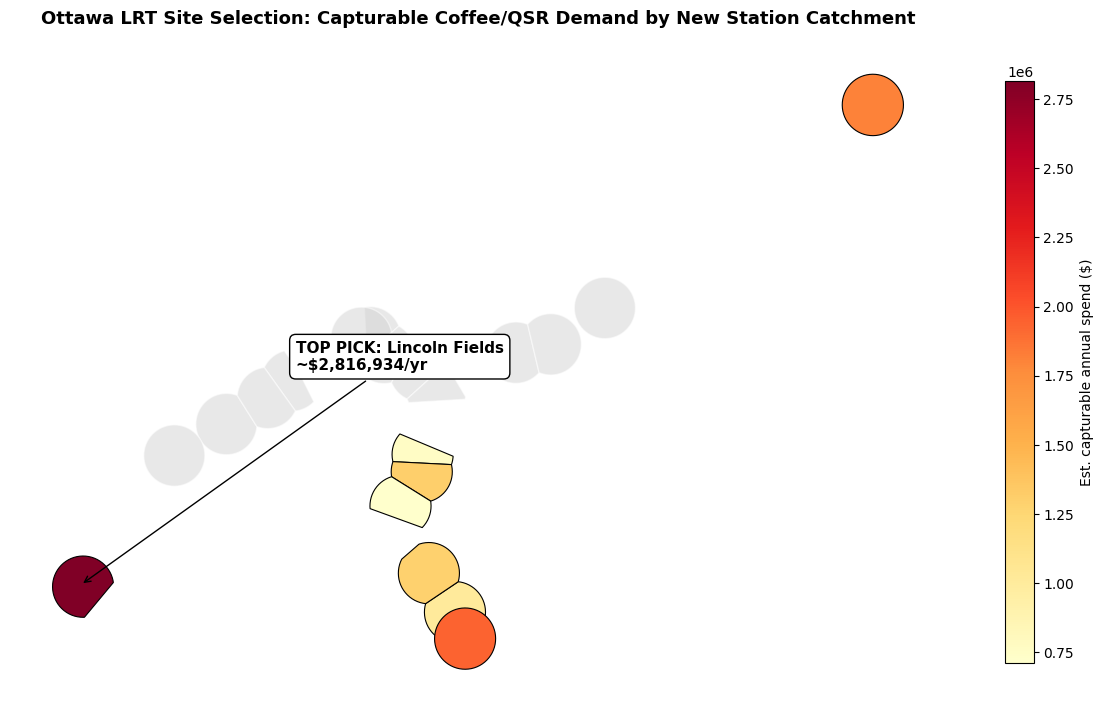

Saved map to Drive


In [27]:
!pip install matplotlib mapclassify -q

import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Reload pieces if session reset (safe to run regardless)
terr = m_gdf.to_crs("EPSG:3857")  # web mercator for basemap alignment

# Merge opportunity dollars onto territories
terr = terr.merge(
    huff[["NAME", "status", "annual_capturable_$"]],
    on=["NAME", "status"], how="left"
)

new = terr[terr["status"] == "LRT_new"].copy()
est = terr[terr["status"] == "LRT_established"].copy()

fig, ax = plt.subplots(figsize=(12, 10))

# Established stations: faint grey context
est.plot(ax=ax, color="lightgrey", edgecolor="white", alpha=0.5)

# New stations: shaded by opportunity ($)
new.plot(
    ax=ax, column="annual_capturable_$", cmap="YlOrRd",
    edgecolor="black", linewidth=0.8, legend=True,
    legend_kwds={"label": "Est. capturable annual spend ($)", "shrink": 0.6},
)

# Label the top pick
top = new.sort_values("annual_capturable_$", ascending=False).iloc[0]
cx, cy = top.geometry.centroid.x, top.geometry.centroid.y
ax.annotate(
    f"TOP PICK: {top['NAME']}\n~${top['annual_capturable_$']:,.0f}/yr",
    xy=(cx, cy), xytext=(cx + 8000, cy + 8000),
    fontsize=11, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"),
)

ax.set_title(
    "Ottawa LRT Site Selection: Capturable Coffee/QSR Demand by New Station Catchment",
    fontsize=13, fontweight="bold", pad=15,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ottawa_site_selection_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved map to Drive")

Basemap added


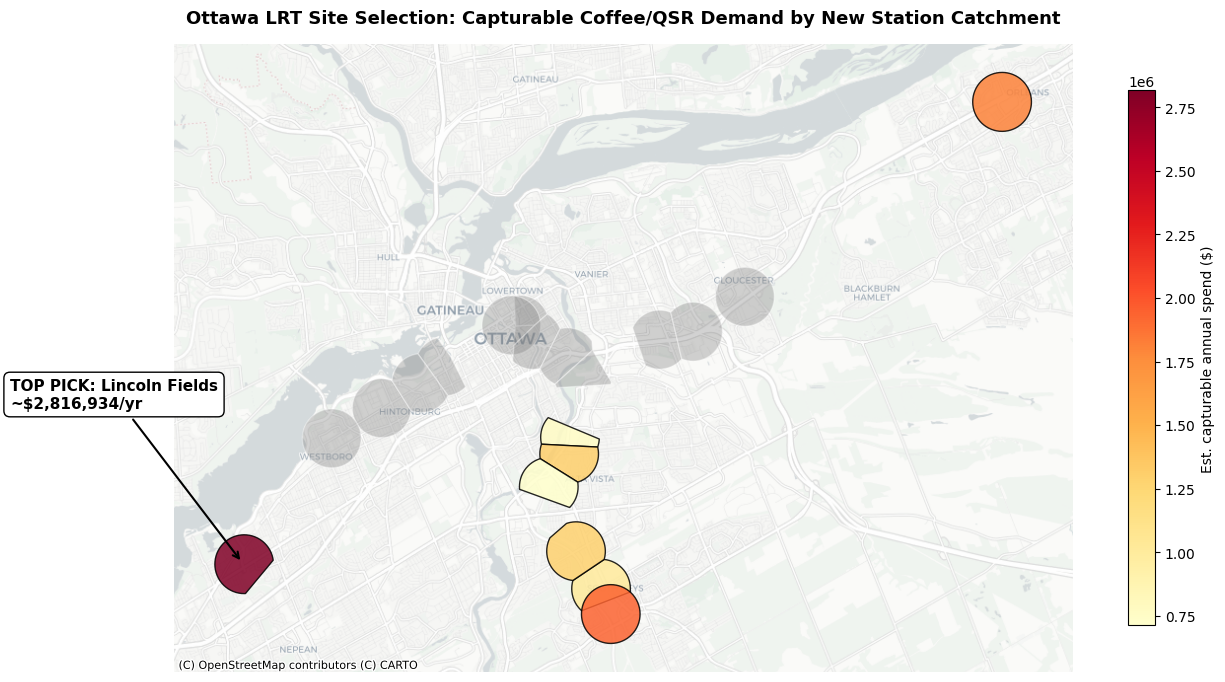

In [28]:
!pip install contextily -q

import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx

# Everything in web mercator (required for basemap alignment)
terr = m_gdf.to_crs("EPSG:3857")
terr = terr.merge(
    huff[["NAME", "status", "annual_capturable_$"]],
    on=["NAME", "status"], how="left"
)
new = terr[terr["status"] == "LRT_new"].copy()
est = terr[terr["status"] == "LRT_established"].copy()

fig, ax = plt.subplots(figsize=(13, 11))

est.plot(ax=ax, color="grey", edgecolor="white", alpha=0.35)
new.plot(
    ax=ax, column="annual_capturable_$", cmap="YlOrRd",
    edgecolor="black", linewidth=1.0, alpha=0.85, legend=True,
    legend_kwds={"label": "Est. capturable annual spend ($)", "shrink": 0.5},
)

# Top pick label
top = new.sort_values("annual_capturable_$", ascending=False).iloc[0]
cx_, cy_ = top.geometry.centroid.x, top.geometry.centroid.y
ax.annotate(
    f"TOP PICK: {top['NAME']}\n~${top['annual_capturable_$']:,.0f}/yr",
    xy=(cx_, cy_), xytext=(cx_ - 9000, cy_ + 6000),
    fontsize=11, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"),
)

# THE KEY ADDITION: real Ottawa map tiles behind everything
try:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=12)
    print("Basemap added")
except Exception as e:
    print("Basemap failed (network?):", e)
    print("Shapes still plotted; we'll try an alternative if needed.")

ax.set_title(
    "Ottawa LRT Site Selection: Capturable Coffee/QSR Demand by New Station Catchment",
    fontsize=13, fontweight="bold", pad=15,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ottawa_site_selection_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
import pandas as pd

path = "/content/drive/MyDrive/BuildingPermits2026.xlsx"

# See the tab names first
xl = pd.ExcelFile(path)
print("Sheet names:", xl.sheet_names)

Sheet names: ['January 2026', 'February 2026', 'March 2026', 'April 2026', 'May 2026', 'June 2026']


In [15]:
import pandas as pd

path = "/content/drive/MyDrive/BuildingPermits2026.xlsx"
months = ["January 2026", "February 2026", "March 2026",
          "April 2026", "May 2026", "June 2026"]

# Load each month and stack them into one table
frames = []
for m in months:
    df_m = pd.read_excel(path, sheet_name=m)
    df_m["source_month"] = m
    frames.append(df_m)

permits = pd.concat(frames, ignore_index=True)

print("Total permit rows across 6 months:", len(permits))
print("\nColumns:", permits.columns.tolist())
permits.head()

Total permit rows across 6 months: 4013

Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'PERMITS ISSUED', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Report Run:', datetime.datetime(2026, 2, 6, 15, 50, 6, 31000), 'source_month', datetime.datetime(2026, 3, 6, 11, 34, 14, 635000), 'Unnamed: 9', 'Unnamed: 10']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,PERMITS ISSUED,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Report Run:,2026-02-06 15:50:06.031000,source_month,2026-03-06 11:34:14.635000,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,2026-JAN-01 TO 2026-JAN-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January 2026,NaN,NaN,NaN
1,NaN,NaN,NaN,COMMUNITIES: All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January 2026,NaN,NaN,NaN
2,NaN,NaN,NaN,WARDS: All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January 2026,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January 2026,NaN,NaN,NaN
4,NaN,NaN,NaN,"PERMIT TYPES: Change of Use (No Construction),...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,January 2026,NaN,NaN,NaN


In [16]:
import pandas as pd

path = "/content/drive/MyDrive/BuildingPermits2026.xlsx"

# Read January with NO header, so we see every raw row
raw = pd.read_excel(path, sheet_name="January 2026", header=None)
print("Shape:", raw.shape)
for i in range(15):
    # Show first few cells of each row to spot where real headers are
    row_preview = raw.iloc[i].dropna().tolist()[:6]
    print(i, "|", row_preview)

Shape: (452, 11)
0 | ['PERMITS ISSUED', 'Report Run:', datetime.datetime(2026, 2, 6, 15, 50, 6, 31000)]
1 | ['2026-JAN-01 TO 2026-JAN-31']
2 | ['COMMUNITIES: All']
3 | ['WARDS: All']
4 | []
5 | ['PERMIT TYPES: Change of Use (No Construction), Construction Permit, Demolition Permit, Pool Enclosure Permit, Temporary Permit']
6 | ['AMENDMENT TYPES: Revision to Permit, Revision to Permit - Model Change, Revision to Permit - Phasing']
7 | []
8 | ['STREET ADDRESS', 'POSTAL CODE', 'WARD', 'ISSUED DATE', 'BUILDING TYPE', 'COMMUNITY']
9 | ['100 BILL LEATHEM DR', 'K2J0R3', '24', datetime.datetime(2026, 1, 2, 0, 0), 'Retail', 'Nepean']
10 | ['156 BEGONIA AVE\n', 'K1H6E4', '18', datetime.datetime(2026, 1, 2, 0, 0), 'Single', 'Old Ottawa']
11 | ['415 GREENVIEW Drive', '7', datetime.datetime(2026, 1, 2, 0, 0), 'Apartment', 'Old Ottawa', 'Interior alterations to a 21 storey apartment building (Install maglocks)']
12 | ['1250 OLD INNES RD', 'K1B5L3', '18', datetime.datetime(2026, 1, 2, 0, 0), 'Retail'

In [17]:
import pandas as pd

path = "/content/drive/MyDrive/BuildingPermits2026.xlsx"
months = ["January 2026", "February 2026", "March 2026",
          "April 2026", "May 2026", "June 2026"]

frames = []
for m in months:
    # header is on row 8 (0-indexed), so skip rows 0-7
    df_m = pd.read_excel(path, sheet_name=m, header=8)
    df_m["source_month"] = m
    frames.append(df_m)

permits = pd.concat(frames, ignore_index=True)

# Drop fully empty rows (footer/summary junk at the bottom of each tab)
permits = permits.dropna(how="all")

print("Total permit rows:", len(permits))
print("Columns:", permits.columns.tolist())
permits.head(10)

Total permit rows: 3965
Columns: ['STREET ADDRESS', 'POSTAL CODE', 'WARD', 'ISSUED DATE', 'BUILDING TYPE', 'COMMUNITY', 'DESCRIPTION', 'D.U.', 'VALUE', 'SQUARE METRES', 'PERMIT NUMBER', 'source_month']


,STREET ADDRESS,POSTAL CODE,WARD,ISSUED DATE,BUILDING TYPE,COMMUNITY,DESCRIPTION,D.U.,VALUE,SQUARE METRES,PERMIT NUMBER,source_month
0,100 BILL LEATHEM DR,K2J0R3,24.0,2026-01-02,Retail,Nepean,Construct a 2 storey retail office & warehouse...,0.0,1831916.97,1501,CON-2025-013272,January 2026
1,156 BEGONIA AVE\n,K1H6E4,18.0,2026-01-02,Single,Old Ottawa,Construct a 1 storey addition to a 2 storey de...,0.0,64021.95,32,CON-2025-016765,January 2026
2,415 GREENVIEW Drive,NaN,7.0,2026-01-02,Apartment,Old Ottawa,Interior alterations to a 21 storey apartment ...,0.0,3000.00,1,CON-2025-018240,January 2026
3,1250 OLD INNES RD,K1B5L3,18.0,2026-01-02,Retail,Old Ottawa,PLUMBING ONLY: Install a premise isolation dev...,0.0,0.00,0,CON-2025-018438,January 2026
4,992 NEVILLE ST\n,K2B5W2,7.0,2026-01-02,Single,Old Ottawa,Install a woodstove and chimney in a 1 storey ...,0.0,9500.00,4,CON-2025-018820,January 2026
5,1050 BARNETT DR\n,K4C1C7,1.0,2026-01-05,Single,Cumberland,Install an enclosure for an above ground pool ...,0.0,0.00,0,A19-006689,January 2026
6,1108 MAISONNEUVE ST\n,K1C1L1,1.0,2026-01-05,Apartment,Gloucester,Construct a 4 storey apartment building (24 un...,24.0,2632982.92,1316.04,CON-2024-004869,January 2026
7,139 SPRUCE ST OUEST/WEST,K1R6P1,14.0,2026-01-05,Office,Old Ottawa,Construct a 2 storey addition to a 2 storey of...,0.0,418151.68,220,CON-2025-006306,January 2026
8,282 GINEBIK Way,K1X0H5,22.0,2026-01-05,Single,Gloucester,Finish the basement in a 2 storey detached dwe...,NaN,50000.00,70.63,CON-2025-014648,January 2026
9,325 RIDEAU ST,K1N5Y4,12.0,2026-01-05,Other,Old Ottawa,PLUMBING ONLY: Install a premise isolation bac...,0.0,15000.00,3,CON-2025-014738,January 2026


In [18]:
import pandas as pd

# Clean up the postal code column (strip spaces, uppercase)
permits["POSTAL CODE"] = permits["POSTAL CODE"].astype(str).str.strip().str.upper()
permits["postal_prefix"] = permits["POSTAL CODE"].str[:3]

# Your top 3 stations and their approximate postal prefixes
# Lincoln Fields area ~ K2B, South Keys ~ K1V/K1T, Place d'Orleans ~ K1C/K1E
# Let's see what prefixes exist so we pick the right ones
print("Most common postal prefixes in the permit data:")
print(permits["postal_prefix"].value_counts().head(30))

Most common postal prefixes in the permit data:
postal_prefix
K0A    338
K2J    305
K4A    255
K2S    193
K4M    189
NAN    155
K2W    144
K1S    142
K2K    118
K1V    113
K1G    104
K1N    103
K1Y     99
K1T     99
K2E     89
K1Z     87
K2G     86
K2C     84
K1C     83
K2B     81
K1K     81
K1J     81
K1H     71
K1W     71
K2H     70
K2A     66
K1R     58
K1X     57
K2M     57
K2V     50
Name: count, dtype: int64


In [19]:
import pandas as pd

# Clean text fields
permits["STREET ADDRESS"] = permits["STREET ADDRESS"].astype(str).str.upper().str.strip()
permits["DESCRIPTION"] = permits["DESCRIPTION"].astype(str)

# Lincoln Fields area
lf = permits[permits["postal_prefix"] == "K2B"].copy()

# Flag permits on the key streets near the station
key_streets = ["CARLING", "RICHMOND", "LINCOLN", "WOODROFFE"]
lf["near_station"] = lf["STREET ADDRESS"].apply(
    lambda a: any(s in a for s in key_streets)
)

lf_near = lf[lf["near_station"]]

print(f"Total K2B permits: {len(lf)}")
print(f"On key streets near Lincoln Fields station: {len(lf_near)}\n")

# Show what's happening near the station, sorted by value (bigger = more significant)
cols = ["STREET ADDRESS", "BUILDING TYPE", "VALUE", "D.U.", "DESCRIPTION", "source_month"]
print(lf_near[cols].sort_values("VALUE", ascending=False).to_string(index=False))

Total K2B permits: 81
On key streets near Lincoln Fields station: 14

  STREET ADDRESS BUILDING TYPE     VALUE  D.U.                                                                                                                                                                                        DESCRIPTION  source_month
1195 RICHMOND RD     Apartment 987683.26   0.0                                                                                                                           Exterior Alterations to a 19 storey apartment building (Balcony Repairs)    April 2026
2301 CARLING AVE        Office 795000.00   0.0                                                                                                                   Tenant fit-up on the 3rd floor of a 3 storey office building (Kelly Santini LLP)     June 2026
2400 CARLING AVE     Apartment 330000.00   0.0                                                                                                             Exterio

In [21]:
import pandas as pd

def check_station(area_prefixes, key_streets, station_name):
    # Filter to the station's postal area(s)
    area = permits[permits["postal_prefix"].isin(area_prefixes)].copy()
    area["near_station"] = area["STREET ADDRESS"].apply(
        lambda a: any(s in a for s in key_streets)
    )
    near = area[area["near_station"]]

    print("=" * 70)
    print(f"{station_name}  (prefixes: {', '.join(area_prefixes)})")
    print("=" * 70)
    print(f"Total permits in area: {len(area)} | On key streets: {len(near)}")

    # Food-service signal: search description for relevant words
    food_words = ["restaurant", "cafe", "coffee", "food", "tim hortons",
                  "starbucks", "qsr", "eatery", "bakery", "drive-thru", "drive thru"]
    desc_lower = near["DESCRIPTION"].str.lower()
    food = near[desc_lower.apply(lambda d: any(w in d for w in food_words))]

    # Residential-growth signal: new dwelling units
    growth = near[near["D.U."].fillna(0) > 0]

    print(f"Food-service permits near station: {len(food)}")
    print(f"Permits adding dwelling units (growth): {len(growth)}"
          f"  (total new units: {growth['D.U.'].sum():.0f})\n")

    # Show what's on the key streets, biggest first
    cols = ["STREET ADDRESS", "BUILDING TYPE", "VALUE", "D.U.", "DESCRIPTION"]
    print(near[cols].sort_values("VALUE", ascending=False).head(15).to_string(index=False))
    print()

    if len(food) > 0:
        print(">>> FOOD-SERVICE PERMITS FOUND:")
        print(food[cols].to_string(index=False))
    else:
        print(">>> No food-service permits found near this station.")
    print()

# South Keys (K1V and K1T cover the area; Bank St is the key corridor)
check_station(
    ["K1V", "K1T"],
    ["BANK", "SOUTH KEYS", "JOHNSTON", "DAZE"],
    "SOUTH KEYS"
)

# Place d'Orleans (K1C is the area; St-Joseph and Centrum are key)
check_station(
    ["K1C", "K1E"],
    ["ST-JOSEPH", "ST JOSEPH", "SAINT-JOSEPH", "CENTRUM", "ORLEANS", "JEANNE"],
    "PLACE D'ORLEANS"
)

SOUTH KEYS  (prefixes: K1V, K1T)
Total permits in area: 212 | On key streets: 14
Food-service permits near station: 1
Permits adding dwelling units (growth): 1  (total new units: 144)

                               STREET ADDRESS BUILDING TYPE       VALUE  D.U.                                                                                                    DESCRIPTION
2425 BANK ST\n1311 HUNT CLUB RD\n2431 BANK ST     Apartment 32521751.14 144.0            Revision: PARTIAL PERMIT: Construct a 14 storey addition to an apartment building (Foundation Only)
                             1319 JOHNSTON RD         Other  1663343.97   0.0                       Construct a 1 storey industrial shell building (Building G)(F3 Occupancy Classification)
                                 2210 BANK ST        Retail   300000.00   0.0                                      Interior alterations in a 1 storey retail building (Marshalls Homesense) 
                             3484 LIMEBANK RD         Other

In [22]:
import geopandas as gpd
import pandas as pd

# Reload competitors if needed
comp = pd.read_csv("/content/drive/MyDrive/competitors.csv")
comp_gdf = gpd.GeoDataFrame(
    comp, geometry=gpd.points_from_xy(comp["lon"], comp["lat"]), crs="EPSG:4326"
).to_crs("EPSG:32618")

# Reload station territories, get South Keys point
terr = gpd.read_file("/content/drive/MyDrive/station_territories.geojson").to_crs("EPSG:32618")
sk = terr[terr["NAME"].str.contains("South Keys", case=False)]
sk_point = sk.geometry.iloc[0].centroid

# Competitors within 1.5km of South Keys station
comp_gdf["dist_m"] = comp_gdf.geometry.distance(sk_point)
nearby = comp_gdf[comp_gdf["dist_m"] <= 1500].sort_values("dist_m")

print(f"Competitors within 1.5km of South Keys: {len(nearby)}\n")
print(nearby[["name", "amenity", "brand", "dist_m"]].to_string(index=False))

Competitors within 1.5km of South Keys: 6

         name   amenity      brand     dist_m
   McDonald's fast_food McDonald's 154.341053
    Starbucks      cafe  Starbucks 364.361259
Bombay Garden fast_food        NaN 487.800105
     Crispy's fast_food        NaN 595.738933
   Sushi Shop fast_food Sushi Shop 696.687257
Zait & Zaatar fast_food        NaN 967.949299


In [23]:
import geopandas as gpd
import pandas as pd

# --- Reload everything fresh ---
comp = pd.read_csv("/content/drive/MyDrive/competitors.csv")
comp_gdf = gpd.GeoDataFrame(
    comp, geometry=gpd.points_from_xy(comp["lon"], comp["lat"]), crs="EPSG:4326"
).to_crs("EPSG:32618")

terr = gpd.read_file("/content/drive/MyDrive/station_territories.geojson").to_crs("EPSG:32618")
huff = pd.read_csv("/content/drive/MyDrive/FINAL_huff_full.csv")

# Words that indicate a direct coffee competitor
coffee_brands = ["starbucks", "tim hortons", "second cup", "bridgehead",
                 "coffee", "cafe", "café"]

def is_coffee(row):
    text = f"{row['name']} {row['brand']}".lower()
    if row["amenity"] == "cafe":
        return True
    return any(c in text for c in coffee_brands)

comp_gdf["is_coffee"] = comp_gdf.apply(is_coffee, axis=1)

stations = ["Lincoln Fields", "South Keys", "Place d'Orleans"]

for name in stations:
    st = terr[terr["NAME"].str.contains(name, case=False)]
    if len(st) == 0:
        print(f"[{name}] not found in territories\n")
        continue
    pt = st.geometry.iloc[0].centroid

    comp_gdf["d"] = comp_gdf.geometry.distance(pt)
    near = comp_gdf[comp_gdf["d"] <= 1500].copy()
    coffee = near[near["is_coffee"]].sort_values("d")
    nearest_coffee = coffee["d"].min() if len(coffee) else None

    # model dollar figure
    row = huff[huff["NAME"].str.contains(name, case=False)]
    dollars = row["annual_capturable_$"].iloc[0] if len(row) else float("nan")

    print("=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)
    print(f"Model capturable $/yr:     ${dollars:,.0f}")
    print(f"Total competitors (1.5km): {len(near)}")
    print(f"Direct COFFEE competitors: {len(coffee)}")
    if nearest_coffee is not None:
        print(f"Nearest coffee competitor: {nearest_coffee:.0f}m")
    else:
        print("Nearest coffee competitor: NONE within 1.5km")
    if len(coffee):
        print("\nCoffee competitors nearby:")
        print(coffee[["name", "brand", "d"]].to_string(index=False))
    print()

LINCOLN FIELDS
Model capturable $/yr:     $2,816,934
Total competitors (1.5km): 5
Direct COFFEE competitors: 1
Nearest coffee competitor: 1444m

Coffee competitors nearby:
           name brand           d
Queensview Cafe   NaN 1444.074129

SOUTH KEYS
Model capturable $/yr:     $1,942,323
Total competitors (1.5km): 6
Direct COFFEE competitors: 1
Nearest coffee competitor: 364m

Coffee competitors nearby:
     name     brand          d
Starbucks Starbucks 364.361259

PLACE D'ORLEANS
Model capturable $/yr:     $1,806,189
Total competitors (1.5km): 10
Direct COFFEE competitors: 0
Nearest coffee competitor: NONE within 1.5km

